# 🔍 Meme Search Demo

Тестируем FAISS-индексы: текстовый поиск, поиск по картинке, гибридный.

In [1]:
import os
# Отключаем параллелизм OpenMP — иначе на macOS падает (конфликт libomp)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ['VECLIB_MAXIMUM_THREADS'] = '1'
os.environ['NUMEXPR_NUM_THREADS'] = '1'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['TORCH_NUM_THREADS'] = '1'


In [2]:
import sys
sys.path.insert(0, '../.venv/lib/python3.13/site-packages')


In [3]:
import json
import numpy as np
import faiss
from pathlib import Path
from IPython.display import display, Image as IPImage
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Пути
DATA_DIR = Path('../data/processed')
TEXT_INDEX_PATH = DATA_DIR / 'faiss_text.index'
IMAGE_INDEX_PATH = DATA_DIR / 'faiss_image.index'
METADATA_PATH = DATA_DIR / 'index_metadata.jsonl'

print('Loading FAISS indices...')
text_index = faiss.read_index(str(TEXT_INDEX_PATH))
image_index = faiss.read_index(str(IMAGE_INDEX_PATH))
print(f'Text index: {text_index.ntotal} vectors, dim={text_index.d}')
print(f'Image index: {image_index.ntotal} vectors, dim={image_index.d}')

print('\nLoading metadata...')
metadata = []
with open(METADATA_PATH) as f:
    for line in f:
        line = line.strip()
        if line:
            metadata.append(json.loads(line))
print(f'Metadata: {len(metadata)} records')

Loading FAISS indices...
Text index: 9998 vectors, dim=384
Image index: 9998 vectors, dim=512

Loading metadata...
Metadata: 9998 records


In [4]:
# Загружаем text model один раз
from sentence_transformers import SentenceTransformer

print('Loading SentenceTransformer...')
text_model = SentenceTransformer('all-MiniLM-L6-v2')
print('Done!')

Loading SentenceTransformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done!


In [5]:
def show_results(indices, scores, title='Search Results', max_cols=5):
    """Показывает найденные мемы как сетку картинок."""
    n = len(indices)
    cols = min(n, max_cols)
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3.5, rows * 4))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)
    
    if rows == 1 and cols == 1:
        axes = [[axes]]
    elif rows == 1:
        axes = [axes]
    
    for i, (idx, score) in enumerate(zip(indices, scores)):
        row, col = divmod(i, cols)
        ax = axes[row][col]
        
        meta = metadata[idx]
        img_path = Path('..') / meta.get('source_path', '')
        
        try:
            img = Image.open(img_path).convert('RGB')
            ax.imshow(img)
        except Exception:
            ax.set_facecolor('#2a2a2a')
            ax.text(0.5, 0.5, ' No image', ha='center', va='center',
                    transform=ax.transAxes, color='white')
        
        caption = meta.get('caption', '')[:80]
        ocr = meta.get('ocr_text', '')[:50]
        src = meta.get('source_type', '')
        ax.set_title(f'#{i+1} [{src}] score={score:.3f}\n{caption}', 
                     fontsize=7, wrap=True)
        if ocr:
            ax.set_xlabel(f'OCR: {ocr}', fontsize=6)
        ax.axis('off')
    
    # Скрыть пустые ячейки
    for i in range(n, rows * cols):
        row, col = divmod(i, cols)
        axes[row][col].axis('off')
    
    plt.tight_layout()
    plt.show()


def text_search(query, top_k=5):
    """Поиск по тексту через SentenceTransformer + FAISS."""
    q_emb = text_model.encode([query], normalize_embeddings=True).astype(np.float32)
    scores, indices = text_index.search(q_emb, top_k)
    print(f'Query: "{query}"  →  Top-{top_k} results:')
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        m = metadata[idx]
        print(f'  {rank+1}. score={score:.4f} | {m["filename"]} [{m["source_type"]}]')
        print(f'     {m["caption"][:100]}')
    show_results(indices[0], scores[0], title=f'Text search: "{query}"')
    return indices[0], scores[0]


def image_search(img_path, top_k=5):
    """Поиск по картинке через CLIP."""
    import torch
    from transformers import CLIPProcessor, CLIPModel
    
    # Lazy load CLIP
    if not hasattr(image_search, '_model'):
        print('Loading CLIP...')
        image_search._model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
        image_search._processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
        image_search._model.eval()
        print('CLIP loaded.')
    
    model = image_search._model
    processor = image_search._processor
    
    img = Image.open(img_path).convert('RGB')
    inputs = processor(images=img, return_tensors='pt')
    
    with torch.no_grad():
        vision_out = model.vision_model(pixel_values=inputs['pixel_values'])
        img_feat = model.visual_projection(vision_out.pooler_output)
        img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
    
    q_emb = img_feat.numpy().astype(np.float32)
    scores, indices = image_index.search(q_emb, top_k)
    
    print(f'Image search: {img_path}  →  Top-{top_k}:')
    for rank, (idx, score) in enumerate(zip(indices[0], scores[0])):
        m = metadata[idx]
        print(f'  {rank+1}. score={score:.4f} | {m["filename"]} [{m["source_type"]}]')
    show_results(indices[0], scores[0], title=f'Image search: {Path(img_path).name}')
    return indices[0], scores[0]


def hybrid_search(query, img_path=None, alpha=0.6, top_k=5):
    """
    Гибридный поиск: Reciprocal Rank Fusion (RRF).
    alpha = вес текстового поиска (1-alpha = вес картиночного).
    """
    K = 60  # RRF constant
    rrf_scores = {}
    
    # Текстовый поиск
    q_emb = text_model.encode([query], normalize_embeddings=True).astype(np.float32)
    _, txt_indices = text_index.search(q_emb, top_k * 10)
    for rank, idx in enumerate(txt_indices[0]):
        rrf_scores[idx] = rrf_scores.get(idx, 0) + alpha * (1 / (K + rank + 1))
    
    # Картиночный поиск (если есть)
    if img_path:
        import torch
        from transformers import CLIPProcessor, CLIPModel
        if not hasattr(image_search, '_model'):
            print('Loading CLIP...')
            image_search._model = CLIPModel.from_pretrained('openai/clip-vit-base-patch32')
            image_search._processor = CLIPProcessor.from_pretrained('openai/clip-vit-base-patch32')
            image_search._model.eval()
        
        img = Image.open(img_path).convert('RGB')
        inputs = image_search._processor(images=img, return_tensors='pt')
        with torch.no_grad():
            vision_out = image_search._model.vision_model(pixel_values=inputs['pixel_values'])
            img_feat = image_search._model.visual_projection(vision_out.pooler_output)
            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
        q_img = img_feat.numpy().astype(np.float32)
        _, img_indices = image_index.search(q_img, top_k * 10)
        for rank, idx in enumerate(img_indices[0]):
            rrf_scores[idx] = rrf_scores.get(idx, 0) + (1 - alpha) * (1 / (K + rank + 1))
    
    top = sorted(rrf_scores.items(), key=lambda x: -x[1])[:top_k]
    indices_out = [t[0] for t in top]
    scores_out  = [t[1] for t in top]
    
    tag = f'{query}' + (f' + image' if img_path else '')
    print(f'Hybrid search: "{tag}"')
    for rank, (idx, score) in enumerate(zip(indices_out, scores_out)):
        m = metadata[idx]
        print(f'  {rank+1}. RRF={score:.6f} | {m["filename"]} [{m["source_type"]}]')
        print(f'     {m["caption"][:100]}')
    show_results(indices_out, scores_out, title=f'Hybrid: "{query}"')
    return indices_out, scores_out

print('Functions ready: text_search(), image_search(), hybrid_search()')

Functions ready: text_search(), image_search(), hybrid_search()


##  Текстовый поиск

Query: "apple"  →  Top-5 results:
  1. score=0.5102 | 3d9dfd0beb37.png [telegram]
     A red apple with a face, looking content.
  2. score=0.4982 | b365ff95c64e.jpg [bing]
     A meme showing a debate between Android, Apple, and Nokia, with the final verdict being Nokia.
  3. score=0.4640 | 33ed5ee1bbce.png [telegram]
     A red apple with a face drawn on it, looking confused.
  4. score=0.4593 | b8823d6ff0d2.png [telegram]
     A smiling apple with a playful expression.
  5. score=0.4588 | 8095e483da28.png [telegram]
     A red apple with a smiling face.


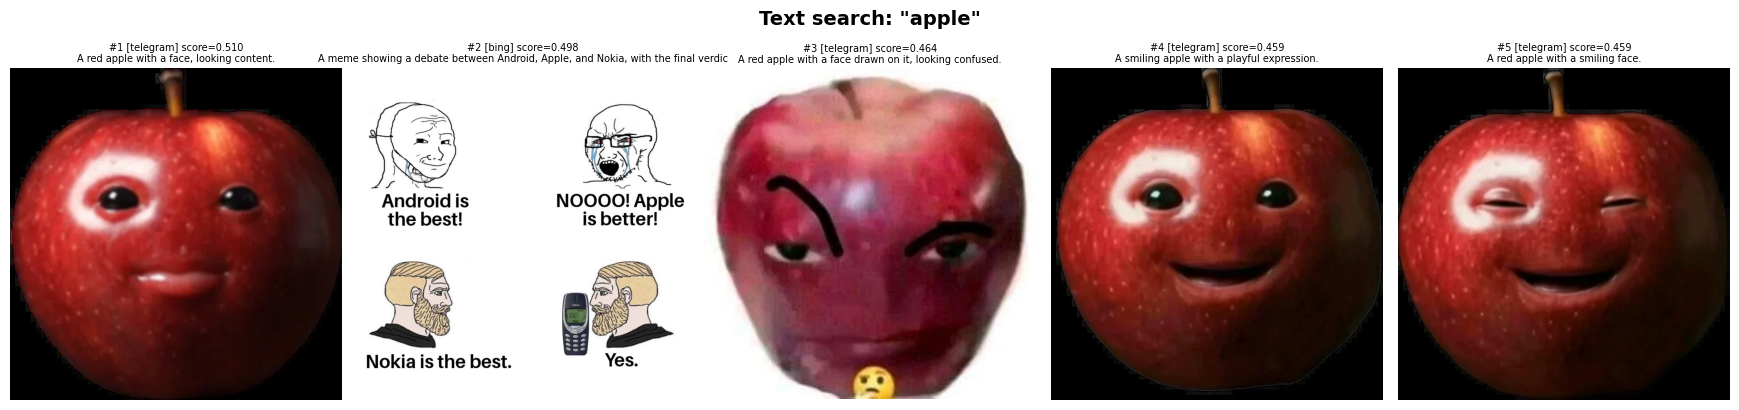

(array([9804, 8206, 8022, 9617, 4462]),
 array([0.5101548 , 0.49822614, 0.46404642, 0.4593056 , 0.45883968],
       dtype=float32))

In [20]:
text_search("apple", top_k=5)

Query: "funny cat meme"  →  Top-5 results:
  1. score=0.6403 | 82d1417f6012.jpg [bing]
     A cat with a slightly funny expression.
  2. score=0.6242 | 82d1417f6012.jpg [bing]
     when the meme is only slightly funny.
  3. score=0.6196 | 1f81aee4f067.jpg [bing]
     A cat meme with a humorous and playful tone.
  4. score=0.6163 | 86bf0f8d59e4.jpg [bing]
     A meme featuring a cat with a grumpy expression and various captions.
  5. score=0.5957 | ec2a198fd04b.jpg [bing]
     A meme showing a cat in a humorous situation.


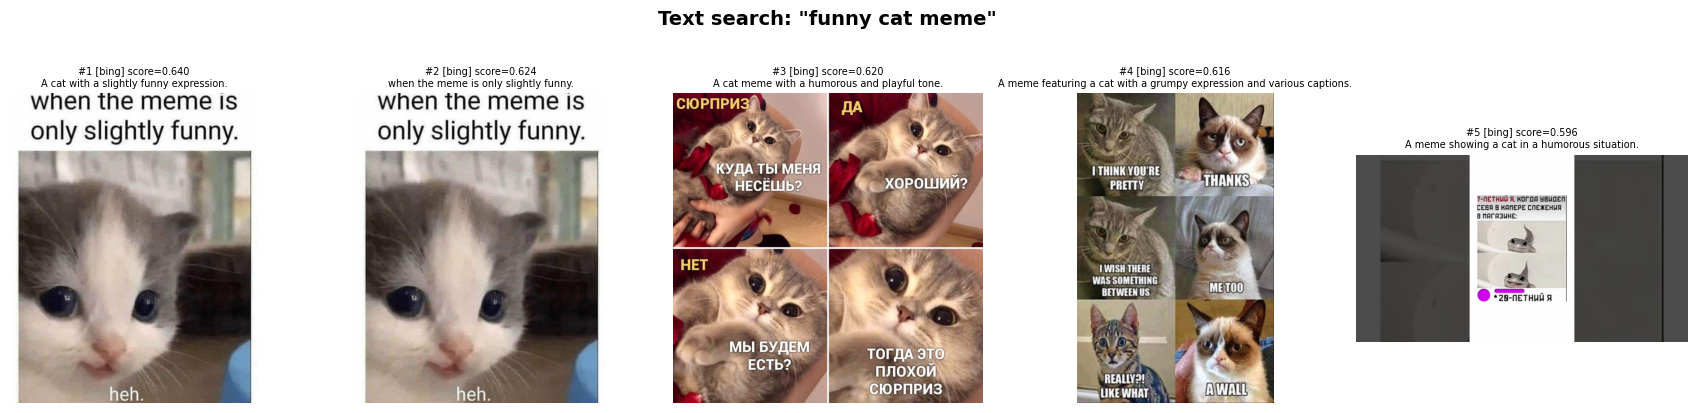

(array([7552, 3519,  901, 2416, 4207]),
 array([0.6403458, 0.6241589, 0.619612 , 0.6162695, 0.5957192],
       dtype=float32))

In [6]:
text_search("funny cat meme", top_k=5)

Query: "programmer debugging code at 3am"  →  Top-5 results:
  1. score=0.3838 | 2ff163a33023.jpg [bing]
     A humorous comic strip depicting the daily routine of programmers, showing their struggle with bugs 
  2. score=0.3800 | de262731b1a8.jpg [bing]
     When you're at work checking the time at it's 3:00pm, then you check again 3 hours later and it's 3:
  3. score=0.3501 | ed1a43c3783a.png [bing]
     A comic strip showing a programmer repeatedly encountering errors while trying to compile code.
  4. score=0.3271 | 0fd19d31fa7d.jpg [bing]
     A person playing a video game at 3 AM, with the caption 'Just one more game' and 'Me at 3 AM:'
  5. score=0.3177 | b4ba5bca855f.jpg [bing]
     A person expressing frustration while trying to learn coding and programming.


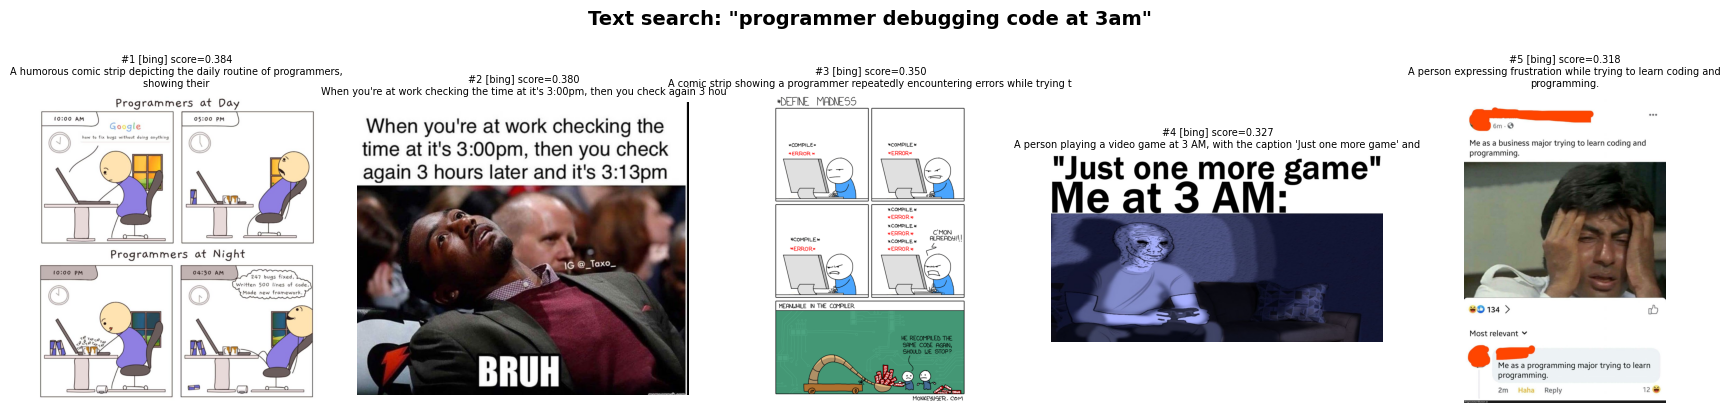

(array([6809, 8705, 9809, 5223, 1903]),
 array([0.3838117 , 0.38000736, 0.35010305, 0.3271375 , 0.31771985],
       dtype=float32))

In [7]:
text_search("programmer debugging code at 3am", top_k=5)

Query: "surprised pikachu face reaction"  →  Top-5 results:
  1. score=0.7202 | 2aa243c53b90.jpg [bing]
     Pikachu looks surprised for some reason!
  2. score=0.6879 | 564354d0e4a9.jpg [bing]
     A surprised Pikachu with wide eyes and a slightly open mouth.
  3. score=0.6737 | be85b6b9178b.png [bing]
     A close-up of Pikachu with a surprised expression.
  4. score=0.6737 | 4773a6dc3dc5.png [bing]
     A close-up of Pikachu with a surprised expression.
  5. score=0.6737 | 27b1e71d6319.jpg [bing]
     A close-up of Pikachu with a surprised expression.


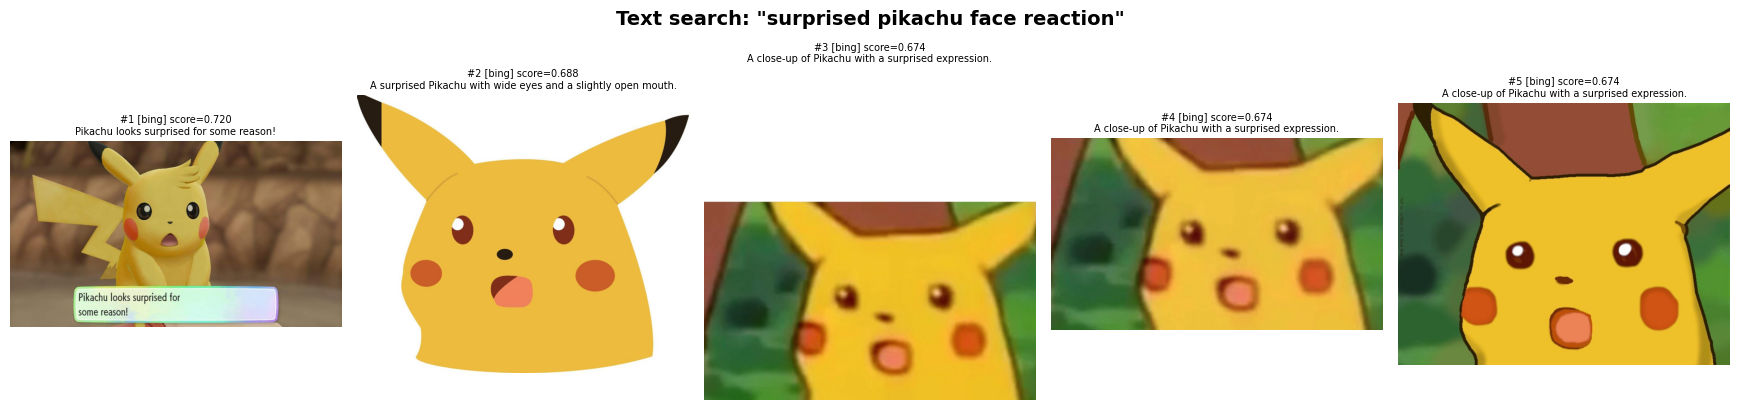

(array([9970, 1080, 3300, 3166,  316]),
 array([0.7201966 , 0.6879301 , 0.67365205, 0.67365205, 0.67365205],
       dtype=float32))

In [8]:
text_search("surprised pikachu face reaction", top_k=5)

Query: "sad frog pepe meme"  →  Top-5 results:
  1. score=0.7761 | f647802da5aa.jpg [bing]
     A green frog with a sad expression against a colorful background.
  2. score=0.6353 | 05594b6f229b.png [bing]
     A pixelated frog with a sad expression.
  3. score=0.6249 | adcd2449b700.png [bing]
     A meme showing a path blocked by a frog, with text indicating it's a bad day at work.
  4. score=0.5864 | 392fb8f51130.webp [bing]
     A collage of various Pepe the Frog images with different expressions and accessories.
  5. score=0.5851 | f30455e39020.jpg [bing]
     A collage of various Pepe the Frog images with a humorous and surreal tone.


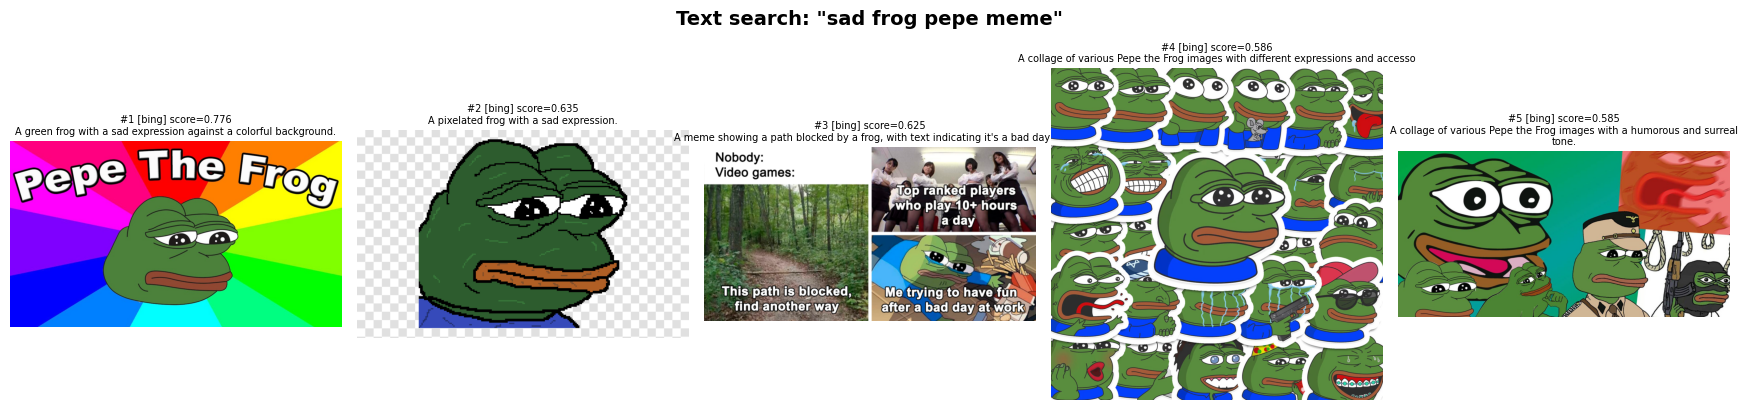

(array([9679, 8852, 3066, 8456, 7740]),
 array([0.77605504, 0.63534653, 0.62491834, 0.58644134, 0.58513093],
       dtype=float32))

In [9]:
text_search("sad frog pepe meme", top_k=5)

Query: "dog confused sitting"  →  Top-5 results:
  1. score=0.5888 | 3316f5d58297.jpg [bing]
     A dog appears tired and is shown in two different positions, one with its head down and the other wi
  2. score=0.5547 | 5e6ca06e9498.jpg [bing]
     A dog sitting on a stool in a room with a speech bubble saying 'This is fine'.
  3. score=0.5427 | 46e52d95969b.png [telegram]
     A brown and white dog wearing a blue collar sits attentively on a beige carpet.
  4. score=0.5419 | 748869700858.webp [bing]
     A dog is sitting at a desk with a laptop, looking at the screen.
  5. score=0.5373 | ba3fa7812e4a.png [telegram]
     A small dog appears to be confused or sad, with a text overlay about disconnecting from a server.


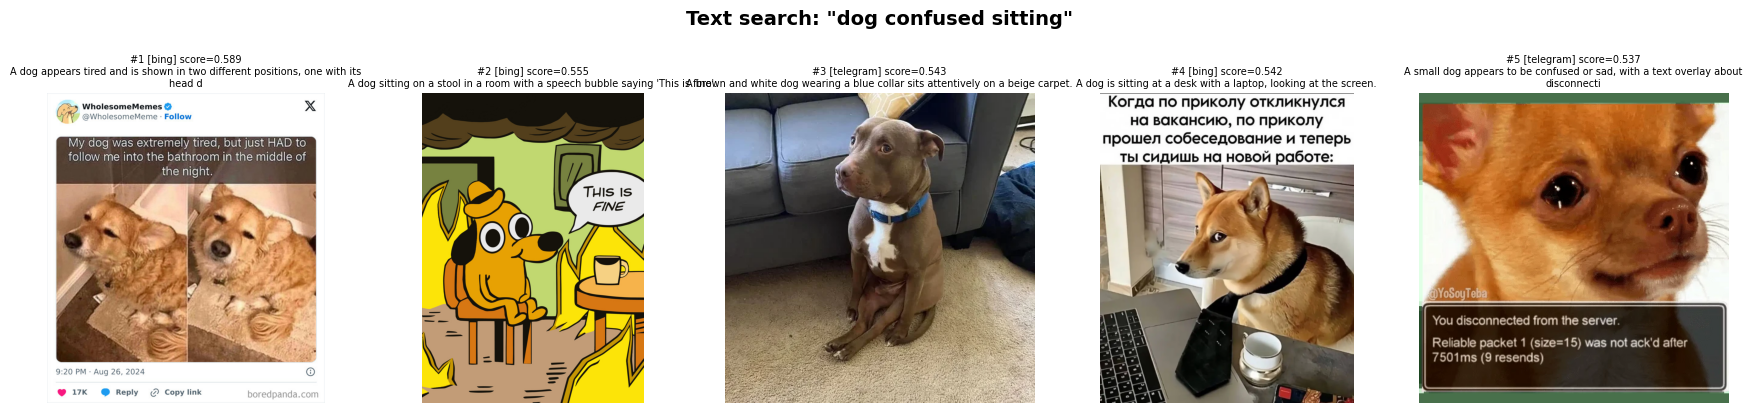

(array([ 266, 3900, 6560, 9988, 9959]),
 array([0.58881456, 0.5547144 , 0.54266   , 0.5418615 , 0.5372649 ],
       dtype=float32))

In [10]:
# Попробуй свои запросы!
text_search("dog confused sitting", top_k=5)

## Поиск по картинке

Укажи путь к любому изображению — найдём похожие мемы.

Query image: data/raw/bing_memes/images/9b6f21f829f9.jpg


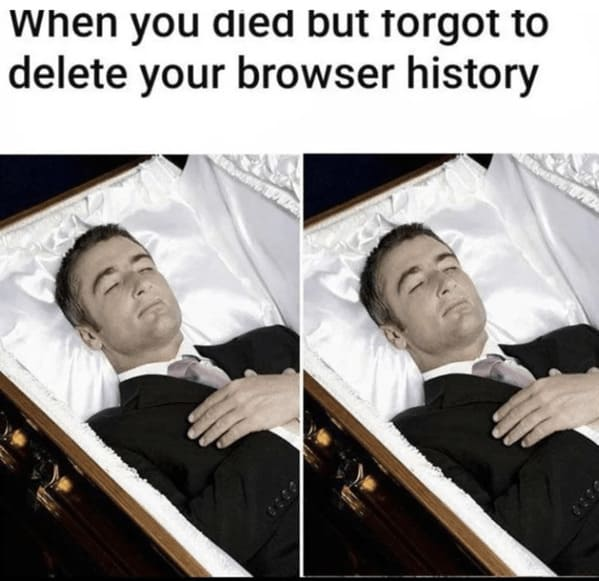

Loading CLIP...


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


CLIP loaded.
Image search: ../data/raw/bing_memes/images/9b6f21f829f9.jpg  →  Top-5:
  1. score=1.0000 | 9b6f21f829f9.jpg [bing]
  2. score=1.0000 | 9b6f21f829f9.jpg [bing]
  3. score=0.7593 | 45647a9c2bc4.jpg [bing]
  4. score=0.7593 | 45647a9c2bc4.jpg [bing]
  5. score=0.7582 | 38d50b8a19a7.jpg [bing]


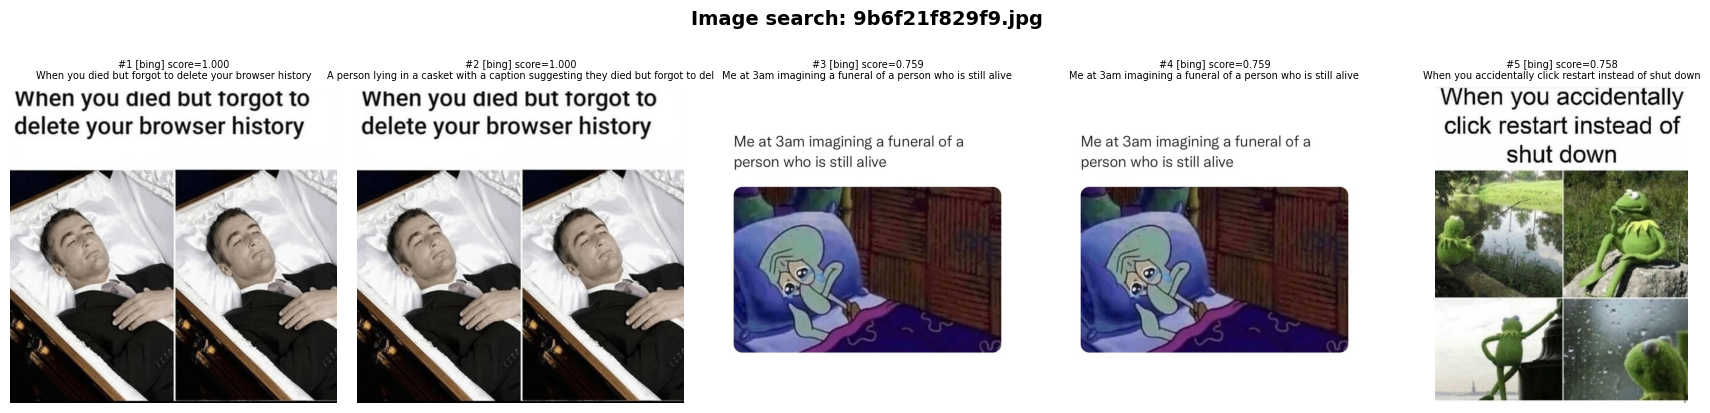

(array([8682,   42, 6323,   43, 7434]),
 array([1.0000001 , 1.0000001 , 0.75932103, 0.75932103, 0.7581639 ],
       dtype=float32))

In [11]:
# Берём первый мем из датасета как пример запроса
sample_path = metadata[42]['source_path']
sample_path_full = Path('..') / sample_path
print(f'Query image: {sample_path}')
display(IPImage(str(sample_path_full), width=300))
image_search(str(sample_path_full), top_k=5)

## Гибридный поиск (текст + картинка)

Hybrid search: "happy dog"
  1. RRF=0.016393 | c3e98b7f74ad.jpg [bing]
     A dog with a happy expression and a message of love and pride.
  2. RRF=0.016129 | c5511febdfd0.jpg [bing]
     This is what happiness looks like
  3. RRF=0.015873 | 850920438edd.jpg [bing]
     A happy dog with its tongue out, captioned 'When you get an A on the test and didn't study'
  4. RRF=0.015625 | 0a2f547ef3c9.jpg [bing]
     A dog with a happy expression and the text 'HI, I'M STOPTHAT. SOMETIMES THEY CALL ME 'GETBACKHERE'.'
  5. RRF=0.015385 | 3f976693c4b1.png [telegram]
     A dog with a happy expression, closing its eyes and smiling.


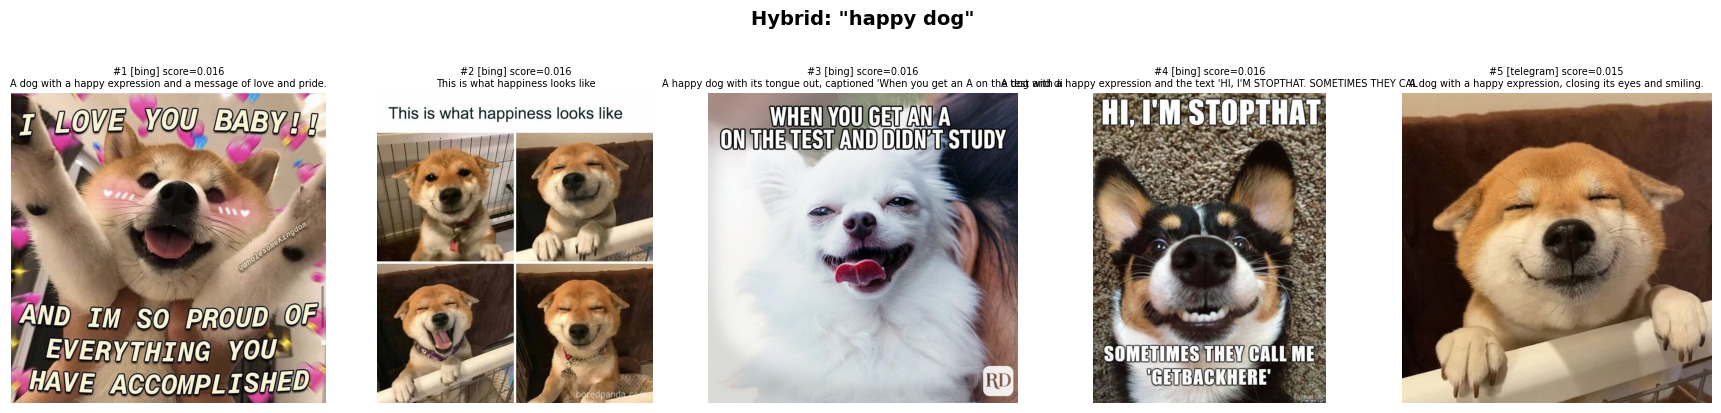

([np.int64(7789),
  np.int64(3474),
  np.int64(2244),
  np.int64(322),
  np.int64(9779)],
 [0.01639344262295082,
  0.016129032258064516,
  0.015873015873015872,
  0.015625,
  0.015384615384615385])

In [12]:
# Только текст в гибридном режиме
hybrid_search("happy dog", alpha=1.0, top_k=5)

Hybrid search: "dog + image"
  1. RRF=0.008197 | aad2908b0e4d.png [telegram]
     A cute, cartoonish dog with a long tongue sticking out.
  2. RRF=0.008197 | 9b6f21f829f9.jpg [bing]
     When you died but forgot to delete your browser history
  3. RRF=0.008065 | aa3bceac8df9.jpg [bing]
     A dog with various phrases overlaid on it.
  4. RRF=0.008065 | 9b6f21f829f9.jpg [bing]
     A person lying in a casket with a caption suggesting they died but forgot to delete their browser hi
  5. RRF=0.007937 | 69401f116b62.png [telegram]
     A fluffy, light brown dog with a curious expression.


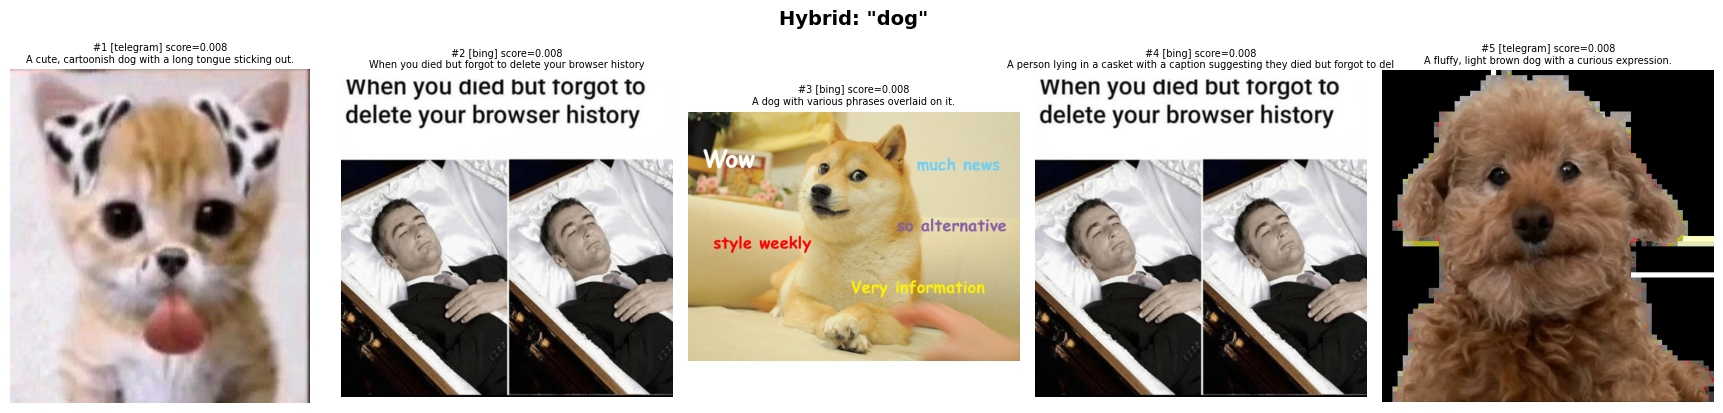

([np.int64(5722),
  np.int64(8682),
  np.int64(3815),
  np.int64(42),
  np.int64(9016)],
 [0.00819672131147541,
  0.00819672131147541,
  0.008064516129032258,
  0.008064516129032258,
  0.007936507936507936])

In [13]:
# Текст + картинка
hybrid_search("dog", img_path=str(sample_path_full), alpha=0.5, top_k=5)

## Статистика индексов

In [14]:
from collections import Counter

sources = Counter(m['source_type'] for m in metadata)
has_caption = sum(1 for m in metadata if m.get('caption'))
has_ocr = sum(1 for m in metadata if m.get('ocr_text'))

print(f'Total memes in index: {len(metadata)}')
print(f'Source distribution: {dict(sources)}')
print(f'Has caption: {has_caption} ({has_caption/len(metadata)*100:.1f}%)')
print(f'Has OCR text: {has_ocr} ({has_ocr/len(metadata)*100:.1f}%)')

Total memes in index: 9998
Source distribution: {'bing': 4207, 'telegram': 5791}
Has caption: 9915 (99.2%)
Has OCR text: 3471 (34.7%)
